# Backends

Deep Agents expose a filesystem surface to the agent via tools like ls, read_file, write_file, edit_file, glob, and grep. These tools operate through a pluggable backend. The read_file tool natively supports image files (.png, .jpg, .jpeg, .gif, .webp) across all backends, returning them as multimodal content blocks.

### The Backends in Deep Agent will helps in following : 
- choose a backend,
- route different paths to different backends,
- implement your own virtual filesystem (e.g., S3 or Postgres),
- set permissions on filesystem access,
- comply with the backend protocol,

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

### There are following prebuilt filesystem backends : 
- StateBackend (Default): The default filesystem backend for an agent is stored in langgraph state.
- FilesystemBackend (Local filesystem persistence): This gives the deep agent access to your local machine’s filesystem. You can specify the root directory that the agent has access to.
- StoreBackend (Durable/Long term store [LangGraph store]): This gives the agent access to long-term storage that is persisted across threads.
- ContextHubBackend: Stores files durably in a LangSmith Hub repo, without provisioning a separate LangGraph store.
- sandbox: Execute code in isolated environments. Sandboxes provide filesystem tools plus the execute tool for running shell commands.
- LocalShellBackend: Filesystem and shell execution directly on the host. No isolation—use only in controlled development environments.
- Composite: Thread-scoped by default, /memories/ persisted across threads. The Composite backend is maximally flexible. You can specify different routes in the filesystem to point towards different backends. 

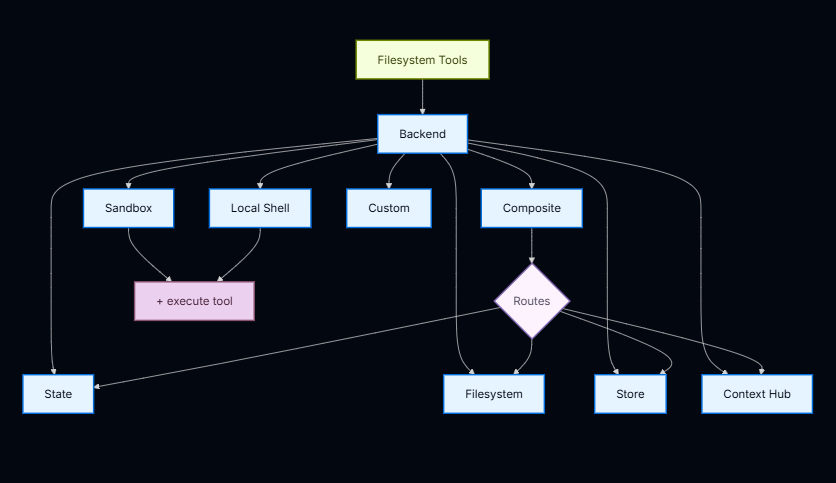

In [2]:
from deepagents import create_deep_agent
from deepagents.backends import StateBackend

In [5]:
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="gemma4:e4b",
    temperature=0.3
)

response = model.invoke("Explain LangChain in one sentence.")

print(response.content)

LangChain is a development framework that simplifies the creation of complex applications by connecting Large Language Models (LLMs) to external data sources, tools, and structured workflows.


In [7]:

# -----------------------------------------------------------------------------
# 1. Create the agent — these two are equivalent
# -----------------------------------------------------------------------------
agent = create_deep_agent(model=model)

# Under the hood this is what `agent` is doing — explicit StateBackend:
agent2 = create_deep_agent(
    model=model,
    backend=StateBackend(),
)

In [8]:

# -----------------------------------------------------------------------------
# 2. Invoke the agent and ask it to WRITE a file
#    (StateBackend keeps that file inside LangGraph state)
# -----------------------------------------------------------------------------
result = agent2.invoke({
    "messages": [{
        "role": "user",
        "content": (
            "Create a file at /notes/todo.txt with exactly this content:\n"
            "1. Record video\n2. Edit video\n3. Upload video\n"
            "Then tell me you've done it."
        )
    }]
})
# The agent's final natural-language reply
print("\n--- Agent reply -------------------------------------------------")
print(result["messages"][-1].content)


--- Agent reply -------------------------------------------------
I've created the file at /notes/todo.txt with the specified content.
